In [6]:
import pickle
with open(r'Y:\xinke\Danmu\DyEmo-submit\emotions27\Behavioral_ratings\ratings27_sorted_final.pkl', 'rb') as f:
    data = pickle.load(f)
print(data.keys())
print(data[0])

dict_keys([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 985, 990, 995, 1000, 1005,

In [7]:
import numpy as np
data_keys = list(data.keys())
time_points = np.zeros(len(data_keys))
data_mean = np.zeros((len(data_keys), 27))
for i in range(len(data_keys)):
    time_points[i] = data_keys[i]
    data_mean[i,:] = np.mean(np.array(data[data_keys[i]]), axis=1)

In [8]:
import numpy as np
rating_lens = np.zeros((len(data.keys()),27))
for i in range(len(data_keys)):
    for j in range(27):
        rating_lens[i,j] = len(data[data_keys[i]][j])
print(np.min(rating_lens), np.max(rating_lens), np.mean(rating_lens))

3.0 4.0 3.125


In [9]:
rating_3 = np.zeros((1152, 27, 3))
for i in range(len(data_keys)):
    # print(data[data_keys[i]])
    for j in range(27):
        for k in range(3):
            rating_3[i,j,k] = data[data_keys[i]][j][k]

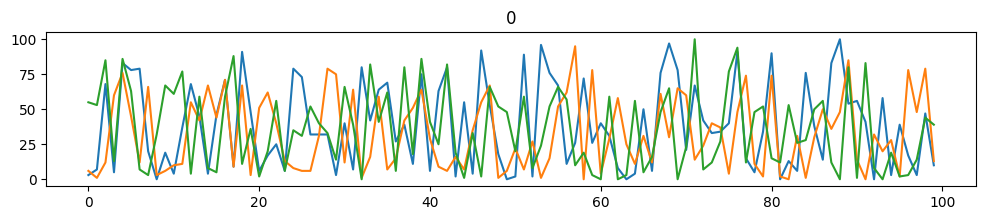

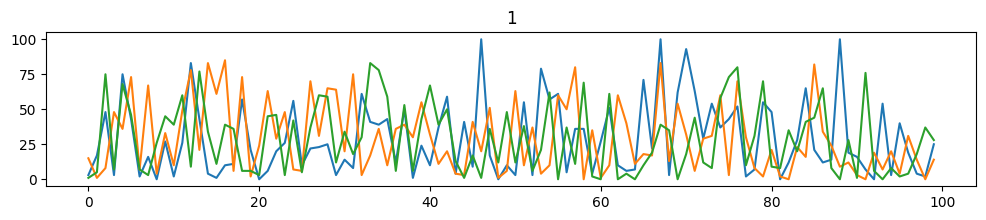

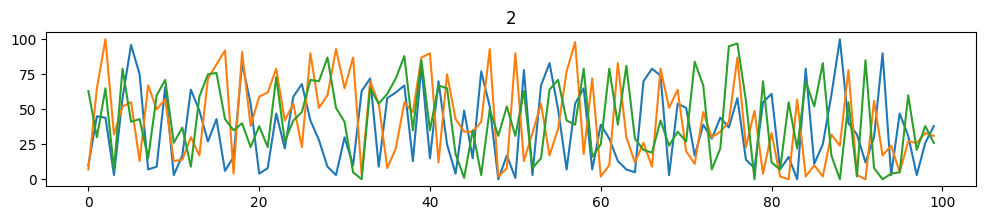

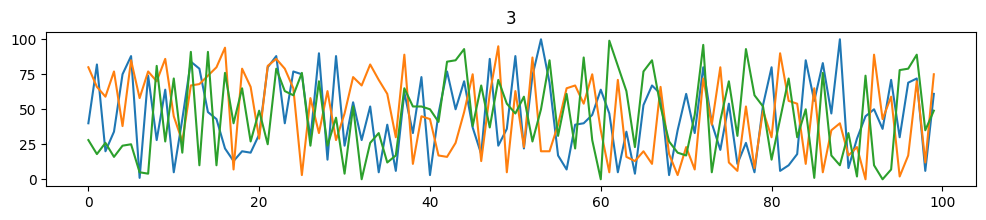

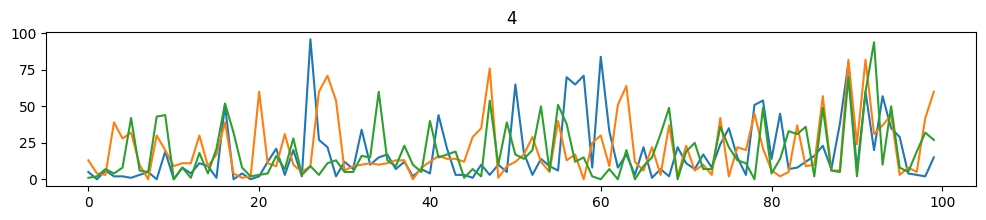

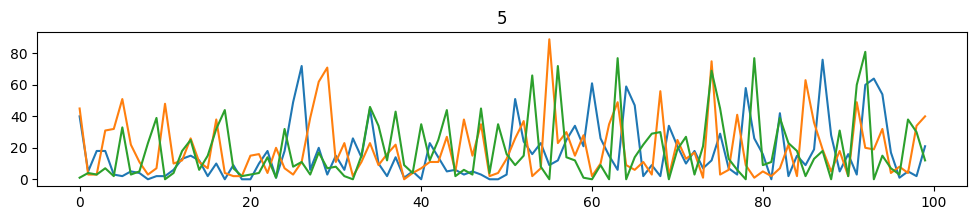

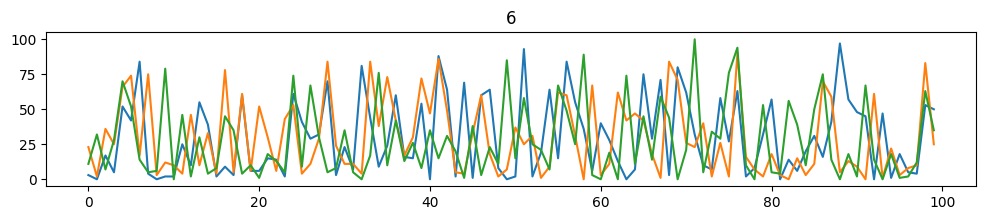

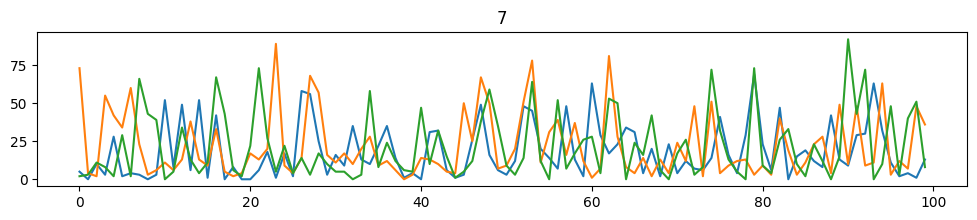

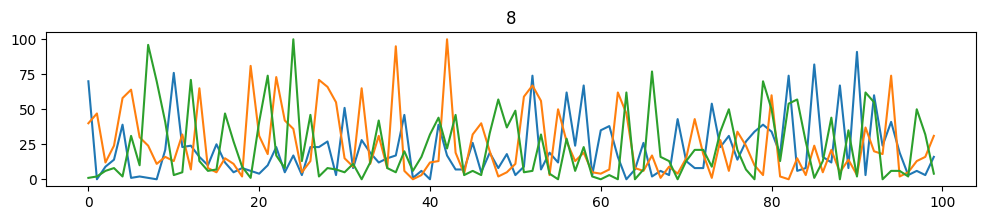

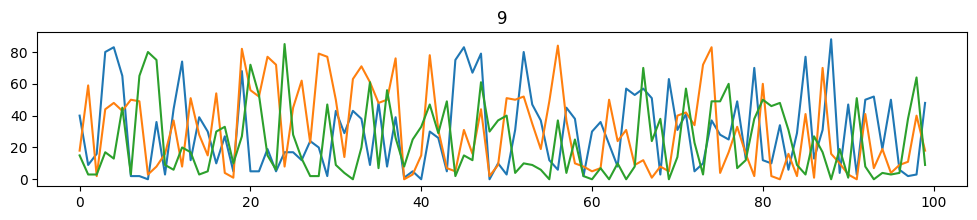

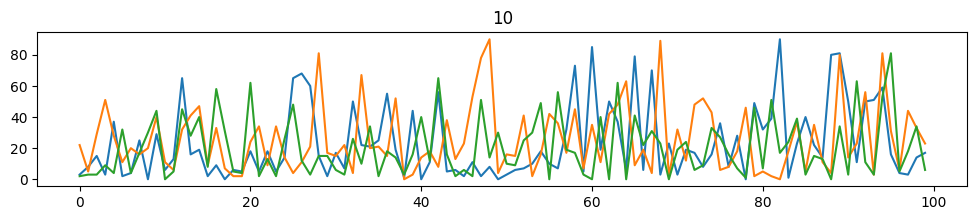

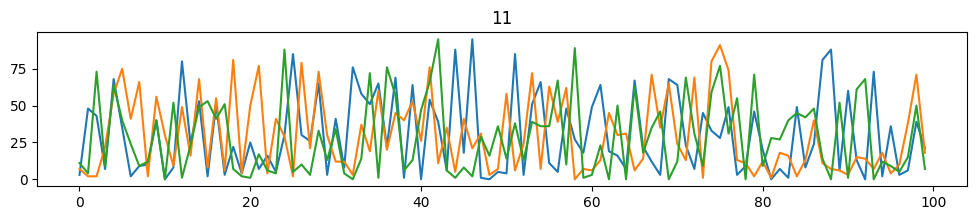

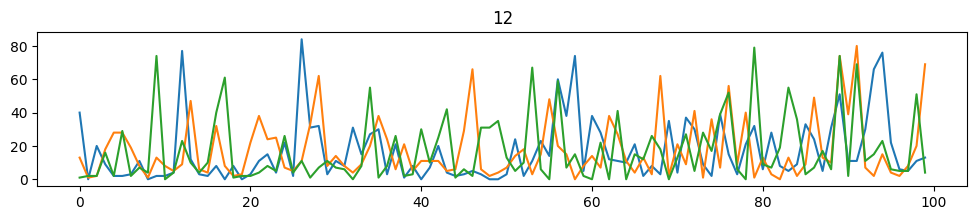

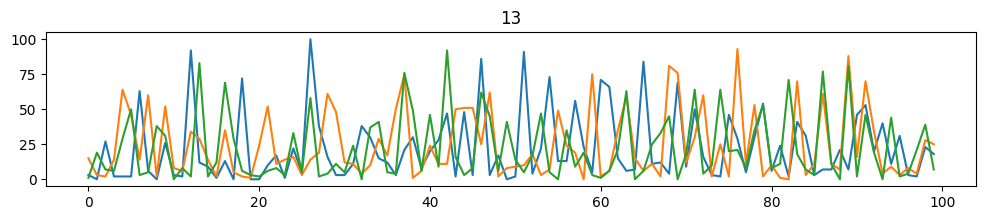

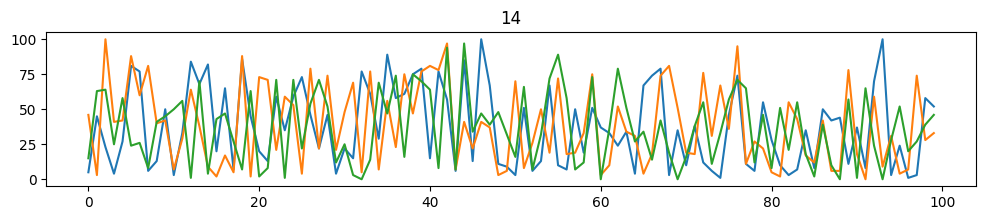

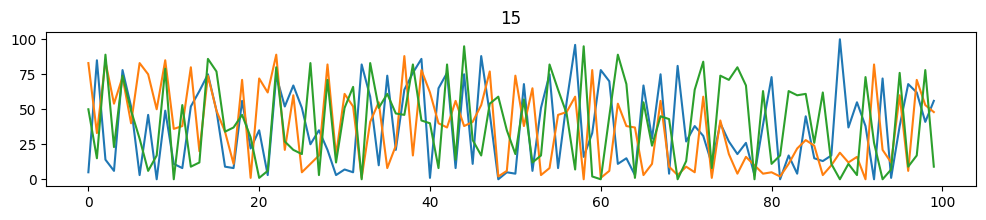

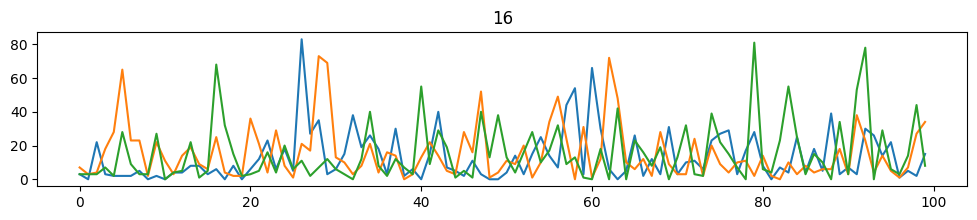

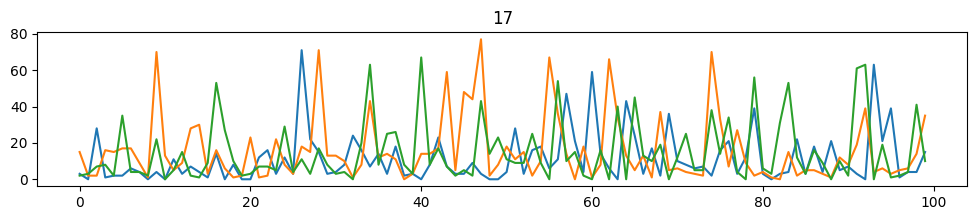

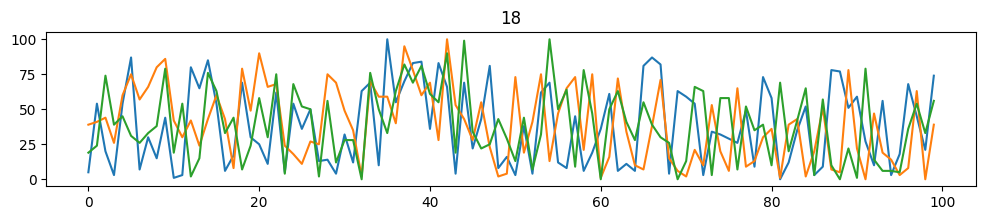

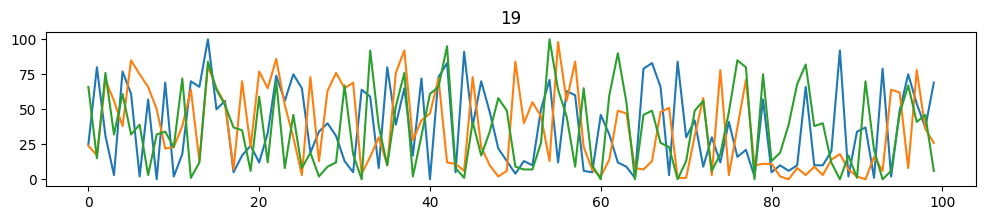

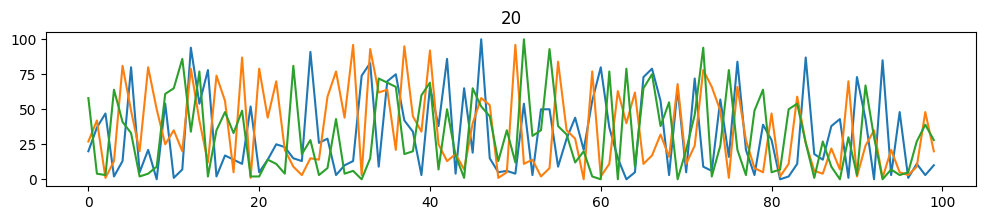

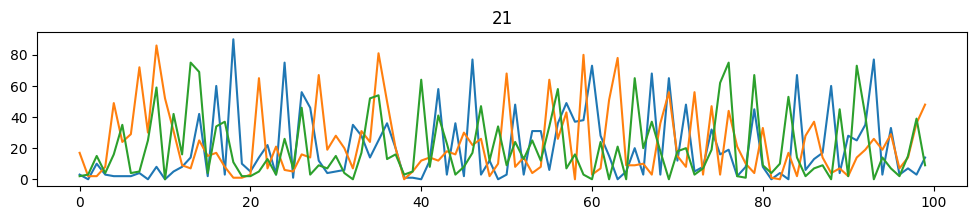

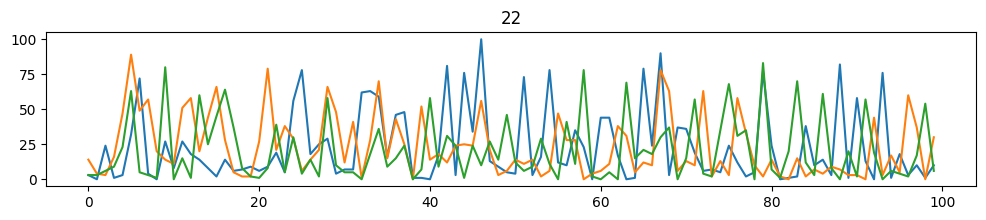

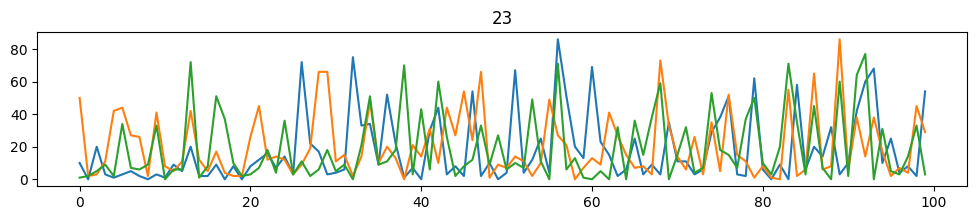

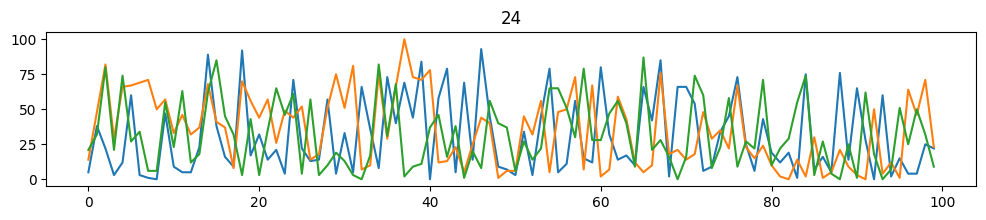

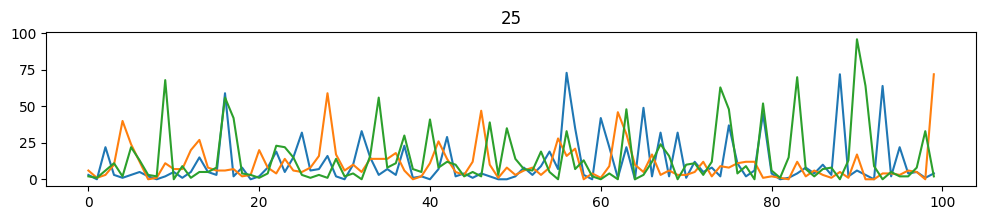

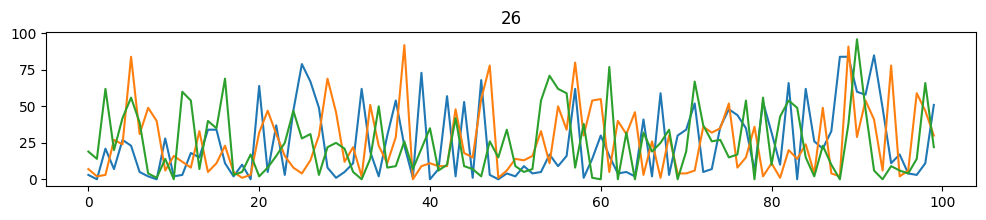

In [10]:
import matplotlib.pyplot as plt
for j in range(27):
    plt.figure(figsize=(12,2))
    plt.title(j)
    for k in range(3):
        plt.plot(rating_3[:100,j,k])
    plt.show()

In [11]:
np.triu_indices(3,1)

(array([0, 0, 1]), array([1, 2, 2]))

In [12]:
rs_human = np.zeros((27,3,3))
for i in range(3):
    for j in range(i+1,3):
        for k in range(27):
            rs_human[k,i,j] = np.corrcoef(rating_3[:,k,i], rating_3[:,k,j])[0,1]
r_mean = np.zeros(27)
for k in range(27):
    r_mean[k] = np.mean(rs_human[k][np.triu_indices(3,1)])
print(r_mean)

[ 0.12985824  0.06994801  0.08896024  0.14305326  0.15031866  0.05601476
  0.09816912  0.02237404 -0.04797557 -0.04991027  0.11478116  0.03174942
  0.0580576   0.1582937   0.03273787  0.10977455  0.07823116  0.05513754
 -0.0020218   0.11505907  0.00933407  0.03675985  0.08304397  0.16137316
  0.03291844  0.07885237  0.04427241]


In [13]:
print(data_mean.shape)
print(data_mean)
print(time_points)

(1152, 27)
[[21.33333333  6.33333333 26.66666667 ... 13.33333333  3.66666667
   9.66666667]
 [21.75       22.75       53.         ... 34.5         3.25
  13.        ]
 [55.         43.66666667 69.66666667 ... 61.33333333 10.33333333
  28.66666667]
 ...
 [33.66666667 26.         38.33333333 ... 24.33333333  5.
  16.33333333]
 [ 9.33333333  7.66666667  4.66666667 ... 35.33333333  6.66666667
   4.66666667]
 [48.66666667 40.33333333 64.66666667 ... 35.66666667 10.
  17.33333333]]
[0.000e+00 5.000e+00 1.000e+01 ... 5.745e+03 5.750e+03 5.755e+03]


In [15]:
from copy import deepcopy

# with open(r'Y:\xinke\Danmu\DyEmo-film\Processed_danmu\movie_batch1\danmu_forrest_gump_downsample.pkl', 'rb') as f:
with open(r'Y:\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']
print(len(time_ranges))

5756


In [16]:
n_emos = 27

In [17]:
# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])

# Downsample
time_points = time_points[np.arange(0,5756,5)]

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,n_emos))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, data_mean[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, n_emos))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

danmu_human_ratings = deepcopy(preds_cut_resample)

In [18]:
# Smooth the predicted scores over Ts windows
smooth_win = 10
danmu_human_smoothed = np.zeros(danmu_human_ratings.shape)
for i in range(danmu_human_ratings.shape[0]):
    tmp = danmu_human_ratings[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
    danmu_human_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)

In [23]:
import matplotlib as mpl
import os
import json
import matplotlib.pyplot as plt

def read_scores_moreEmo(file):
    file_name = file.split('.')[0]
    with open(r'Y:\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
        danmu_dict = pickle.load(f)
    if file_name == 'forrest_gump':
        time_ranges = danmu_dict['forrest_gump.csv_time_range']
    else:
        time_ranges = danmu_dict['%s_time_range' % file]
    seg_count = len(time_ranges)
    
    time_points = np.zeros(len(time_ranges))
    for i in range(len(time_points)):
        time_points[i] = np.mean(time_ranges[i])

    datadir = os.path.join(r'Y:\xinke\Danmu\DyEmo-submit\emotions27\Emotion_scores\prompt_v4_moreEmo\movie_batch1', file_name)
    file_names2 = os.listdir(datadir)
    n_files = len(file_names2)
    # if n_files != seg_count:
    #     Warning('The number of files is not equal to segment counts!')
    #     print('n_files:', n_files, 'seg_count:', seg_count)
    scores_all = np.zeros((seg_count, 27))
    
    is_missing = 0
    missing_files = []
    for count in range(seg_count):
        # print(count)
        file_score = '%.3f_%.3f.json' % (time_ranges[count][0], time_ranges[count][1])
        if file_score not in file_names2:
            print(file_score)
            Warning('%s is not in the folder!' % file_score)
            missing_files.append(file_score)
            is_missing = 1
            continue
        with open(os.path.join(datadir, file_score), 'r', encoding='utf-8') as file_score:
            data = json.load(file_score)            

        # 提取 "content" 字段中的文本
        content = data['choices'][0]['message']['content']

        # 解析文本，将情绪评分提取到列表中
        emotions = ['钦佩', '爱慕', '审美欣赏', '娱乐', '愤怒', '焦虑', '敬畏', '尴尬', '无聊', '平静', '困惑', '渴望', '厌恶', 
                    '共情痛苦', '入迷', '兴奋', '恐惧', '惊悚', '兴趣', '快乐', '怀旧', '解脱', '浪漫', '悲伤', '满足', '性欲', '惊讶']
        scores = []

        # 拆分 content 字符串，并提取每个情绪的评分
        for emotion in emotions:
            start = content.find(emotion) + len(emotion) + 2
            end = content.find(";", start)
            if end == -1:  # 最后一个情绪评分后没有分号
                end = len(content)
            # score = int(content[start:end].strip().rstrip('.'))
            # score = int(content[start:end].strip())
            try:
                score = float(content[start:end].strip())
            except:
                if content[start] == '[':
                    score = float(content[start+1:end-1].strip())
                else:
                    score = float(content[start:end].strip()[:-1])
            scores.append(score)
            
        scores_all[count] = np.array(scores)
    # if is_missing:
    #     with open(os.path.join(datadir, 'missing_file_%d.pkl' % seg_count), 'wb') as f:
    #         pickle.dump(missing_files, f)
    return scores_all, time_points
        
    
def plot_scores_moreEmo(preds_smoothed, time_points):
    emos = ['Joy', 'Admiration', 'Adoration', 'Excitement', 'Aesthetic Appreciation', 'Interest', 'Relief', 'Romance', 'Satisfaction', 
             'Craving', 'Surprise', 'Calmness', 'Nostalgia', 'Awe', 'Amusement', 'Entrancement', 'Confusion', 'Boredom', 'Anxiety', 'Fear', 
             'Horror', 'Awkwardness', 'Disgust', 'Empathic Pain', 'Sadness', 'Anger', 'Sexual Desire']
    cmap = mpl.colormaps['cool']
    reorder_inds = [19, 1, 2, 16, 3, 18, 21, 22, 25, 12, 27, 10, 20, 7, 4, 15, 11, 9, 6, 17, 17, 8, 13, 14, 23, 5, 26]
    reorder_inds = [reorder_inds[i]-1 for i in range(len(reorder_inds))]
    colors = cmap(np.linspace(0,1,len(emos)))[::-1]
    # print(colors)
    
    plt.figure(figsize=(15, 15))
    for j in range(len(emos)):
        plt.subplot(14,2,j+1)
        plt.plot(time_points[:preds_smoothed.shape[0]], preds_smoothed[:,reorder_inds[j]], color=colors[j], linewidth=0.7)
        plt.xlim([0,max(time_points)])
        plt.ylim([0,7])
        # plt.ylabel('Scores')
        # plt.xlabel('Time/s')
        plt.title(emos[j])

    # 调整布局
    plt.tight_layout()
    # plt.savefig('figures/prompt_v4_gpt4o_longMovie_lineplot.jpg', dpi=300)
    plt.show()
    
def smooth_scores(preds, time_points, smooth_win=10):
    half_win = int(round(smooth_win/2))
    preds_smoothed = np.zeros(preds.shape)
    for i in range(preds.shape[0]):
        preds_smoothed[i,:] = np.mean(preds[abs(time_points[:preds.shape[0]] - time_points[:preds.shape[0]][i]) <= half_win, :], axis=0)
    return preds_smoothed

In [24]:
preds, time_points = read_scores_moreEmo('forrest_gump.csv')

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,n_emos))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, n_emos))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over ts windows
smooth_win = 10
preds_smoothed = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
    preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)

In [ ]:
# emotions = ['钦佩', '爱慕', '审美欣赏', '娱乐', '愤怒', '焦虑', '敬畏', '尴尬', '无聊', '平静', '困惑', '渴望', '厌恶', 
#             '共情痛苦', '入迷', '兴奋', '恐惧', '惊悚', '兴趣', '快乐', '怀旧', '解脱', '浪漫', '悲伤', '满足', '性欲', '惊讶']

In [25]:
from copy import deepcopy
n_emos = 27
emos = ['Joy', 'Admiration', 'Adoration', 'Excitement', 'Aesthetic Appreciation', 'Interest', 'Relief', 'Romance', 'Satisfaction', 
             'Craving', 'Surprise', 'Calmness', 'Nostalgia', 'Awe', 'Amusement', 'Entrancement', 'Confusion', 'Boredom', 'Anxiety', 'Fear', 
             'Horror', 'Awkwardness', 'Disgust', 'Empathic Pain', 'Sadness', 'Anger', 'Sexual Desire']
# reorder_inds = [19, 1, 2, 16, 3, 18, 21, 22, 25, 12, 27, 10, 20, 7, 4, 15, 11, 9, 6, 17, 17, 8, 13, 14, 23, 5, 26]
reorder_inds = [20, 1, 2, 16, 3, 19, 22, 23, 25, 12, 27, 10, 21, 7, 4, 15, 11, 9, 6, 17, 18, 8, 13, 14, 24, 5, 26]
reorder_inds = [reorder_inds[i]-1 for i in range(len(reorder_inds))]
emos_reorder = deepcopy(emos)
for i in range(n_emos):
    emos_reorder[reorder_inds[i]] = emos[i]
print(emos_reorder)

['Admiration', 'Adoration', 'Aesthetic Appreciation', 'Amusement', 'Anger', 'Anxiety', 'Awe', 'Awkwardness', 'Boredom', 'Calmness', 'Confusion', 'Craving', 'Disgust', 'Empathic Pain', 'Entrancement', 'Excitement', 'Fear', 'Horror', 'Interest', 'Joy', 'Nostalgia', 'Relief', 'Romance', 'Sadness', 'Satisfaction', 'Sexual Desire', 'Surprise']


In [27]:
from scipy.stats import pearsonr
rs = np.zeros(n_emos)
ps = np.zeros(n_emos)
for i in range(n_emos):
    # rs[i] = np.corrcoef(preds_smoothed[:,i], danmu_human_smoothed[:,i])[0,1]
    rs[i], ps[i] = pearsonr(preds_smoothed[:,i], danmu_human_smoothed[:,i])
    print(emos_reorder[i], rs[i], ps[i])

Admiration 0.30016490295098 7.877005566981159e-76
Adoration 0.3016182735385692 1.3903610549795703e-76
Aesthetic Appreciation 0.342691343656553 1.0268082425791317e-99
Amusement 0.43238537107974556 6.708067922968515e-164
Anger 0.54606414444193 6.556518034620794e-279
Anxiety 0.3271986668219923 1.4551155309683067e-90
Awe 0.184978292003192 4.564415145691756e-29
Awkwardness 0.19341995201592638 1.128782783589249e-31
Boredom 0.1480618735153943 4.3125901403343593e-19
Calmness 0.10474398666158 2.997337834192748e-10
Confusion 0.24259687125672935 2.2902913716732035e-49
Craving 0.16658383908024038 8.254344654961907e-24
Disgust 0.4266804329291239 3.3609009183011394e-159
Empathic Pain 0.48627077041093186 5.133438026129938e-213
Entrancement 0.13386383904000432 7.369079855878125e-16
Excitement 0.09159104700911047 3.7050471205467845e-08
Fear 0.3193021545450122 4.2295984278607175e-86
Horror 0.14580951185909446 1.4778921247338768e-18
Interest 0.015311145121226812 0.3584744667249634
Joy 0.2875110892425919 

In [28]:
from statsmodels.stats.multitest import multipletests
reject, pvals_corrected, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')
print(pvals_corrected)

[1.93344682e-075 3.75397485e-076 4.62063709e-099 4.52794585e-163
 1.77025987e-277 5.61258848e-090 7.24936523e-029 2.03180901e-031
 6.12841757e-019 3.67855098e-010 4.75675900e-049 1.23815170e-023
 1.81488650e-158 6.93014134e-212 9.47453124e-016 4.16817801e-008
 1.26887953e-085 1.99515437e-018 3.58474467e-001 4.21407906e-069
 4.98603076e-038 2.44836417e-029 2.84712006e-089 8.49452421e-208
 2.93730115e-005 3.70606791e-009 3.11298223e-001]


In [29]:
inds_sorted = np.argsort(rs)[::-1]
emos_sorted = [emos_reorder[i] for i in inds_sorted]

In [30]:
print(emos_sorted)

['Anger', 'Empathic Pain', 'Sadness', 'Amusement', 'Disgust', 'Aesthetic Appreciation', 'Anxiety', 'Romance', 'Fear', 'Adoration', 'Admiration', 'Joy', 'Confusion', 'Nostalgia', 'Awkwardness', 'Relief', 'Awe', 'Craving', 'Boredom', 'Horror', 'Entrancement', 'Calmness', 'Sexual Desire', 'Excitement', 'Satisfaction', 'Surprise', 'Interest']


In [32]:
np.save('results/inds_sorted_27emo_byRHuman.npy', inds_sorted)
with open('results/emos_sorted_27emo_byRHuman.pkl', 'wb') as f:
    pickle.dump(emos_sorted, f)

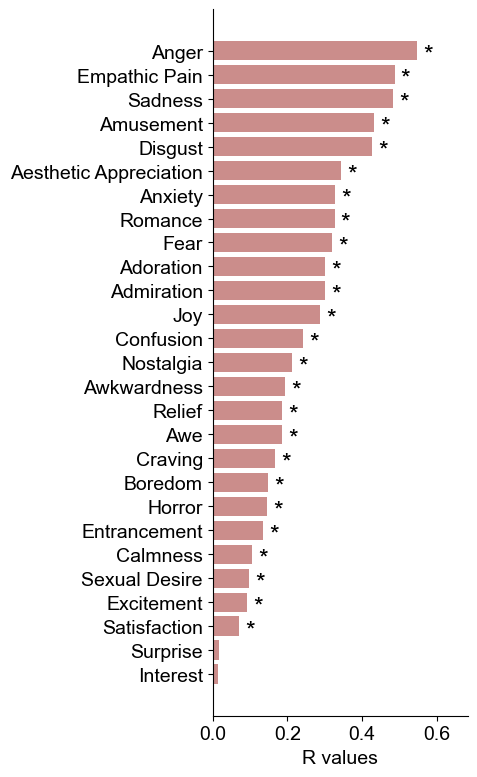

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已有：
# rs: shape (n_emos,)          # 相关系数
# pvals_corrected: shape (n_emos,)   # 校正后的 p 值
# emos: 长度 n_emos 的情绪标签列表
# n_emos = len(rs)

# 1) 按相关系数从大到小排序
order = np.argsort(rs)[::-1]
rs_sorted = np.array(rs)[order]
pvals_sorted = np.array(pvals_corrected)[order]
emos_sorted = np.array(emos_reorder)[order]
n_emos = len(rs_sorted)

# 2) 横向柱状图
plt.figure(figsize=(5, 8))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

y = np.arange(n_emos)
bars = plt.barh(y, rs_sorted, color=[203/255, 141/255, 139/255])

plt.yticks(y, emos_sorted)
plt.xlabel('R values')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 让最大值在上面（可选）
ax.invert_yaxis()

# 3) 在显著的条上加 *
alpha = 0.05
sig_mask = pvals_sorted < alpha

x_max = rs_sorted.max()
plt.xlim(0, x_max * 1.25)  # 给右侧星号留一点空间
star_offset = x_max * 0.03

for i in range(n_emos):
    if sig_mask[i]:
        plt.text(
            rs_sorted[i] + star_offset,  # x 位置：柱子右边一点
            y[i]+0.2,                        # y 对应这一条
            '*',
            ha='left',
            va='center',
            fontsize=18
        )

plt.tight_layout()
plt.savefig('figures/r_human_llm_plain_horizontal.svg', dpi=300)
plt.show()


In [41]:
def read_scores_moreEmo_splitHalf(file, seg_count):
    file_name = file.split('.')[0]
    if file == '阿甘正传-firstHalf.csv':
        with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\emotions27\Processed_danmu\danmu_longvideo_downsample_firstHalf.pkl', 'rb') as f:
            danmu_dict = pickle.load(f)
    elif file == '阿甘正传-secondHalf.csv':
        with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\emotions27\Processed_danmu\danmu_longvideo_downsample_secondHalf.pkl', 'rb') as f:
            danmu_dict = pickle.load(f)
    time_ranges = danmu_dict['%s_time_range' % file]
    
    time_points = np.zeros(len(time_ranges))
    for i in range(len(time_points)):
        time_points[i] = np.mean(time_ranges[i])

    datadir = os.path.join(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\emotions27\Emotion_scores\prompt_v4_moreEmo', file_name)
    file_names2 = os.listdir(datadir)
    n_files = len(file_names2)
    if n_files != seg_count:
        Warning('The number of files is not equal to segment counts!')
        print('n_files:', n_files, 'seg_count:', seg_count)
    scores_all = np.zeros((seg_count, 27))
    
    is_missing = 0
    missing_files = []
    for count in range(seg_count):
        # print(count)
        file_score = '%.3f_%.3f.json' % (time_ranges[count][0], time_ranges[count][1])
        if file_score not in file_names2:
            print(file_score)
            Warning('%s is not in the folder!' % file_score)
            missing_files.append(file_score)
            is_missing = 1
            continue
        with open(os.path.join(datadir, file_score), 'r', encoding='utf-8') as file_score:
            data = json.load(file_score)            

        # 提取 "content" 字段中的文本
        content = data['choices'][0]['message']['content']

        # 解析文本，将情绪评分提取到列表中
        emotions = ['钦佩', '爱慕', '审美欣赏', '娱乐', '愤怒', '焦虑', '敬畏', '尴尬', '无聊', '平静', '困惑', '渴望', '厌恶', 
                    '共情痛苦', '入迷', '兴奋', '恐惧', '惊悚', '兴趣', '快乐', '怀旧', '解脱', '浪漫', '悲伤', '满足', '性欲', '惊讶']
        scores = []

        # 拆分 content 字符串，并提取每个情绪的评分
        for emotion in emotions:
            start = content.find(emotion) + len(emotion) + 2
            end = content.find(";", start)
            if end == -1:  # 最后一个情绪评分后没有分号
                end = len(content)
            # score = int(content[start:end].strip().rstrip('.'))
            # score = int(content[start:end].strip())
            try:
                score = float(content[start:end].strip())
            except:
                if content[start] == '[':
                    score = float(content[start+1:end-1].strip())
                else:
                    score = float(content[start:end].strip()[:-1])
            scores.append(score)
            
        scores_all[count] = np.array(scores)
    if is_missing:
        with open(os.path.join(datadir, 'missing_file_%d.pkl' % seg_count), 'wb') as f:
            pickle.dump(missing_files, f)
    return scores_all, time_points

In [42]:
import pickle
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\emotions27\Processed_danmu\danmu_longvideo_downsample_firstHalf.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
seg_count = len(danmu_dict['阿甘正传-firstHalf.csv'])
scores_all1, time_points1 = read_scores_moreEmo_splitHalf('阿甘正传-firstHalf.csv', seg_count)

with open(r'Y:\xinke\Danmu\DyEmo-submit\emotions27\Processed_danmu\danmu_longvideo_downsample_secondHalf.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
print(danmu_dict.keys())
seg_count = len(danmu_dict['阿甘正传-secondHalf.csv'])
scores_all2, time_points2 = read_scores_moreEmo_splitHalf('阿甘正传-secondHalf.csv', seg_count)

dict_keys(['阿甘正传-secondHalf.csv', '阿甘正传-secondHalf.csv_time_range'])


In [43]:
def align_smooth_scores(preds, time_points):
    # cut predicted scores and time_points_german into 8 runs
    cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]

    time_points_ori = deepcopy(time_points)
    time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
    time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
    time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
    time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

    # Find time points in the german version. (the frame rate was different from the original movie)
    time_points_german = time_points_ori / (25/(24000/1001))
    
    n_emos = preds.shape[1]
    preds_cut = np.zeros((0,n_emos))
    time_points_german_cut = np.zeros(0)
    for i in range(len(cut_index2)):
        preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
        time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

    # Get time of ratings in German version
    time_ratings = []
    seg_lens = [902,882,876,976,924,878,1084,676]
    for i in range(8):
        tmp = np.arange(0,seg_lens[i],2)
        if (i > 0) and (i < 7): # The first and the last runs only have one segment
            tmp = tmp + cut_index2[i*2-1][0]
            tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
        elif i == 7:
            tmp = tmp + cut_index2[i*2-1][0]
        time_ratings.extend(tmp)
        
    # Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
    preds_cut_resample = np.zeros((3599, n_emos))
    for i in range(3599):
        if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
            preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
        else:
            preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

    # Smooth the predicted scores over ts windows
    smooth_win = 10
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    return preds_smoothed

In [44]:
preds_smoothed1 = align_smooth_scores(scores_all1, time_points1)
preds_smoothed2 = align_smooth_scores(scores_all2, time_points2)
print(preds_smoothed1.shape, preds_smoothed2.shape)

(3599, 27) (3599, 27)


In [ ]:
r_split = np.zeros(27)
p_split = np.zeros(27)
for i in range(27):
    r_split[i], p_split[i] = pearsonr(preds_smoothed1[:,i], preds_smoothed2[:,i])
    
reject, pvals_corrected, _, _ = multipletests(p_split, alpha=0.05, method='fdr_bh')
print(pvals_corrected)
inds_sorted2 = np.argsort(r_split)[::-1]
emos_sorted2 = [emos_reorder[i] for i in inds_sorted2]

[6.19336400e-296 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 5.18553884e-199 1.81301584e-145 6.01138050e-180
 5.96766110e-214 1.20460162e-224 6.71282939e-197 1.15028638e-243
 0.00000000e+000 0.00000000e+000 8.97011379e-295 8.97011379e-295
 0.00000000e+000 1.31612483e-167 2.19226441e-242 2.76430060e-213
 5.20731188e-314 5.83541172e-207 0.00000000e+000 0.00000000e+000
 1.65225571e-285 1.25824577e-076 3.40668200e-215]


0.5455074246415018 0.09882458966727231


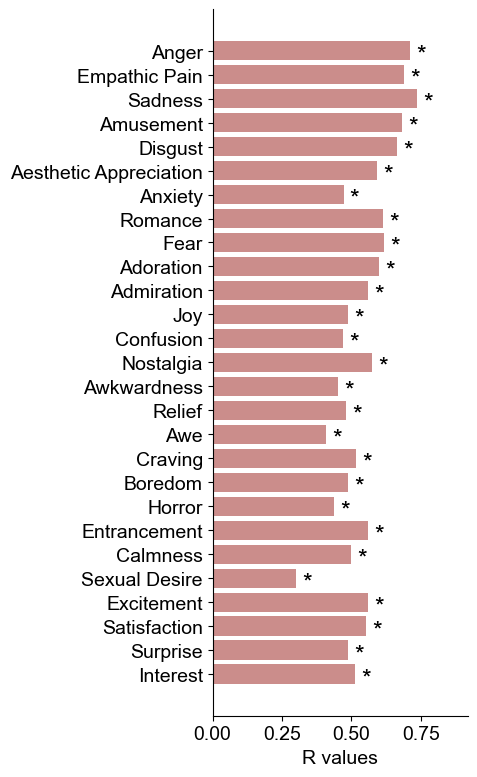

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已有：
# rs: shape (n_emos,)          # 相关系数
# pvals_corrected: shape (n_emos,)   # 校正后的 p 值
# emos: 长度 n_emos 的情绪标签列表
# n_emos = len(rs)

# 1) 按相关系数从大到小排序
# order = np.argsort(rs)[::-1]
rs_sorted = np.array(r_split)[order]
pvals_sorted = np.array(pvals_corrected)[order]
emos_sorted = np.array(emos_reorder)[order]
n_emos = len(rs_sorted)

# 2) 横向柱状图
plt.figure(figsize=(5, 8))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

y = np.arange(n_emos)
bars = plt.barh(y, rs_sorted, color=[203/255, 141/255, 139/255])

plt.yticks(y, emos_sorted)
plt.xlabel('R values')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 让最大值在上面（可选）
ax.invert_yaxis()

# 3) 在显著的条上加 *
alpha = 0.05
sig_mask = pvals_sorted < alpha

x_max = rs_sorted.max()
plt.xlim(0, x_max * 1.25)  # 给右侧星号留一点空间
star_offset = x_max * 0.03

for i in range(n_emos):
    if sig_mask[i]:
        plt.text(
            rs_sorted[i] + star_offset,  # x 位置：柱子右边一点
            y[i]+0.2,                        # y 对应这一条
            '*',
            ha='left',
            va='center',
            fontsize=18
        )

print(np.mean(rs_sorted), np.std(rs_sorted))
plt.tight_layout()
plt.savefig('figures/r_llm_split_horizontal.svg', dpi=300)
plt.show()


In [48]:
from copy import deepcopy
import pickle
import numpy as np

def align_smooth_scores(preds, time_points, smooth_win=10):
    # cut predicted scores and time_points_german into 8 runs
    cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]

    time_points_ori = deepcopy(time_points)
    time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
    time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
    time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
    time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

    # Find time points in the german version. (the frame rate was different from the original movie)
    time_points_german = time_points_ori / (25/(24000/1001))
    
    n_emos = preds.shape[1]
    preds_cut = np.zeros((0,n_emos))
    time_points_german_cut = np.zeros(0)
    for i in range(len(cut_index2)):
        preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
        time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

    # Get time of ratings in German version
    time_ratings = []
    seg_lens = [902,882,876,976,924,878,1084,676]
    for i in range(8):
        tmp = np.arange(0,seg_lens[i],2)
        if (i > 0) and (i < 7): # The first and the last runs only have one segment
            tmp = tmp + cut_index2[i*2-1][0]
            tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
        elif i == 7:
            tmp = tmp + cut_index2[i*2-1][0]
        time_ratings.extend(tmp)
        
    # Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
    preds_cut_resample = np.zeros((3599, n_emos))
    for i in range(3599):
        if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
            preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
        else:
            preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

    # Smooth the predicted scores over ts windows
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    return preds_smoothed, time_ratings


def smooth_scores(preds_cut_resample, time_ratings, smooth_win=10):
    # Smooth the predicted scores over ts windows
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp, axis=0)
    return preds_smoothed

[0.81968832 0.31238283 0.31238283 0.31238283 0.31238283 0.43932874
 0.81968832 0.31238283 0.43932874 0.31238283 0.81968832 0.72365996
 0.31238283 0.31238283 0.81968832 0.43932874 0.43932874 0.81968832
 0.81968832 0.81968832 0.44326463 0.81968832 0.44982874 0.31238283
 0.44326463 0.44982874 0.44326463]


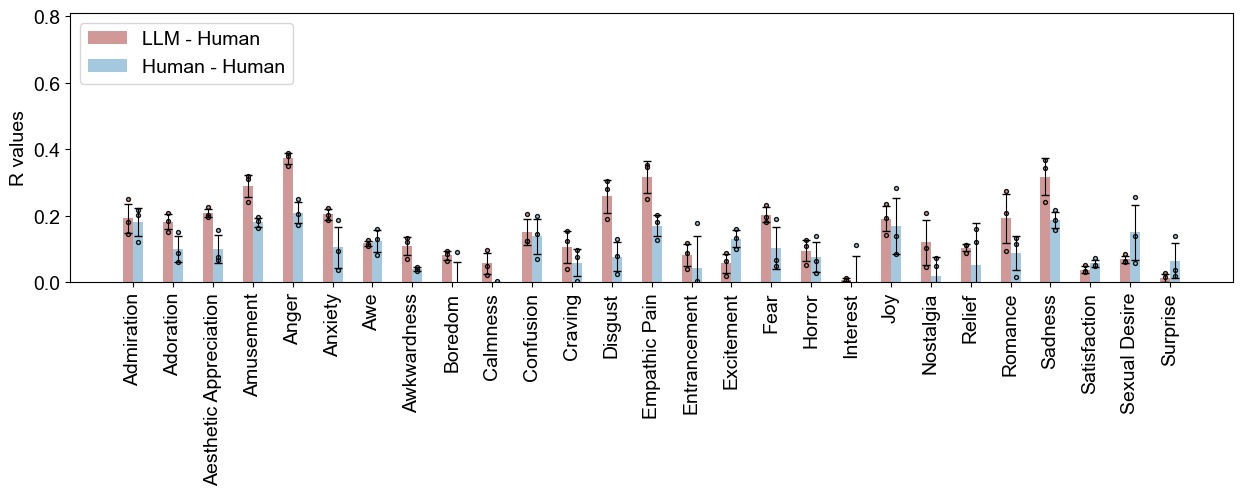

In [49]:
import os
import json
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

def fisher_r_to_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

import os
import json
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\emotions27\Behavioral_ratings\ratings27_sorted_final.pkl', 'rb') as f:
    human_danmu = pickle.load(f)

n_emos = 27
data_keys = np.arange(0,5756,5)
human_danmu_mean = np.zeros((len(data_keys), n_emos))
for i in range(len(data_keys)):
    human_danmu_mean[i,:] = np.mean(np.array(human_danmu[data_keys[i]]), axis=1)
    
human_danmu_3 = np.zeros((1152, n_emos, 3))
for i in range(len(data_keys)):
    # print(data[data_keys[i]])
    for j in range(n_emos):
        for k in range(3):
            human_danmu_3[i,j,k] = human_danmu[data_keys[i]][j][k]

llm_danmu, time_points_llm_danmu = read_scores_moreEmo('forrest_gump')
llm_danmu_aligned, time_ratings = align_smooth_scores(llm_danmu, time_points_llm_danmu)

time_points_human_danmu = time_points_llm_danmu[np.arange(0,5756,5)]
human_danmu_3_aligned = np.zeros((3599,n_emos,3))
for j in range(3):
    human_danmu_3_aligned[:,:,j], _ = align_smooth_scores(human_danmu_3[:,:,j], time_points_human_danmu)
human_danmu_mean_aligned, _ = align_smooth_scores(human_danmu_mean, time_points_human_danmu)


import matplotlib
r_llm_human_danmu = np.zeros((n_emos,3))
for j in range(3):
    for i in range(n_emos):
        r_llm_human_danmu[i,j] = np.corrcoef(llm_danmu_aligned[:,i], human_danmu_3_aligned[:,i,j])[0,1]

r_human_danmu = np.zeros((n_emos,3,3))      
for k in range(3):
    for j in range(k+1,3):
        for i in range(n_emos):
            r_human_danmu[i,k,j] = np.corrcoef(human_danmu_3_aligned[:,i,k], human_danmu_3_aligned[:,i,j])[0,1]  
triu_inds = np.triu_indices(3,1)
# print(np.mean(r_llm_human_danmu, axis=1), np.std(r_llm_human_danmu, axis=1))
# for i in range(6):
    # print(np.mean(r_human_danmu[i,:,:][triu_inds]), np.std(r_human_danmu[i,:,:][triu_inds]))
    
ps = np.zeros(n_emos)
for i in range(n_emos):
    group1_z = fisher_r_to_z(r_llm_human_danmu[i,:])
    group2_z = fisher_r_to_z(r_human_danmu[i,:,:][triu_inds])
    t_stat, p_value = ttest_rel(group1_z, group2_z)
    ps[i] = p_value
    # print(t_stat, p_value)

reject, pvals_corrected, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')
print(pvals_corrected)


matplotlib.rcParams['font.family'] = 'Arial'
emos = ['Joy', 'Admiration', 'Adoration', 'Excitement', 'Aesthetic Appreciation', 'Interest', 'Relief', 'Romance', 'Satisfaction', 
             'Craving', 'Surprise', 'Calmness', 'Nostalgia', 'Awe', 'Amusement', 'Entrancement', 'Confusion', 'Boredom', 'Anxiety', 'Fear', 
             'Horror', 'Awkwardness', 'Disgust', 'Empathic Pain', 'Sadness', 'Anger', 'Sexual Desire']
# reorder_inds = [19, 1, 2, 16, 3, 18, 21, 22, 25, 12, 27, 10, 20, 7, 4, 15, 11, 9, 6, 17, 17, 8, 13, 14, 23, 5, 26]
reorder_inds = [20, 1, 2, 16, 3, 19, 22, 23, 25, 12, 27, 10, 21, 7, 4, 15, 11, 9, 6, 17, 18, 8, 13, 14, 24, 5, 26]
reorder_inds = [reorder_inds[i]-1 for i in range(len(reorder_inds))]
emos_reorder = deepcopy(emos)
for i in range(n_emos):
    emos_reorder[reorder_inds[i]] = emos[i]

bar_width = 0.25
x = np.arange(len(emos_reorder))

fig, ax = plt.subplots(figsize=(15, 3.5))
# ax.bar(x, rs_llm, bar_width, label='LLM', capsize=5, color=[188./255,189./255,50./255])
ax.bar(x, np.mean(r_llm_human_danmu, axis=1), bar_width, yerr=np.std(r_llm_human_danmu, axis=1), 
       error_kw={'capsize': 3, 'elinewidth': 0.8}, label='LLM', capsize=5, color=[203/255,141/255,139/255], alpha=0.9)
r_human_danmu_vec = np.zeros((n_emos,3))
for i in range(n_emos):
    r_human_danmu_vec[i] = r_human_danmu[i,:,:][triu_inds]
ax.bar(x + bar_width, np.mean(r_human_danmu_vec, axis=1), bar_width, yerr=np.std(r_human_danmu_vec, axis=1), 
       error_kw={'capsize': 3, 'elinewidth': 0.8}, label='Human', capsize=5, color=[154/255,196/255,219/255], alpha=0.9)
plt.legend(['LLM - Human', 'Human - Human'], fontsize=14, loc='upper left')
# 添加散点
for i in range(len(emos_reorder)):
    # 对 LLM - Human 添加散点
    ax.scatter(
        np.full_like(r_llm_human_danmu[i, :], x[i]),  # x 坐标
        r_llm_human_danmu[i, :],  # y 坐标
        color=[203/255, 141/255, 139/255],
        s=8,
        edgecolor='black',  # 设置散点边框颜色
        alpha=0.9  # 设置透明度
    )
    # 对 Human - Human 添加散点
    ax.scatter(
        np.full_like(r_human_danmu[i, :, :][triu_inds], x[i] + bar_width),  # x 坐标
        r_human_danmu[i, :, :][triu_inds],  # y 坐标
        color=[154/255, 196/255, 219/255],
        s=8,
        edgecolor='black',  # 设置散点边框颜色
        alpha=0.9  # 设置透明度
    )

# 设置 x 轴刻度
ax.set_xticks(x + bar_width/2, emos_reorder, fontsize=14, rotation=90)
plt.yticks(np.arange(0,0.81,0.2), fontsize=14)

plt.ylabel('R values', fontsize=14)
plt.ylim([0, 0.81])
plt.savefig('figures/r_llm_human_danmu_27emo.svg', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
r_llm_human_danmu.shape

(27, 3)

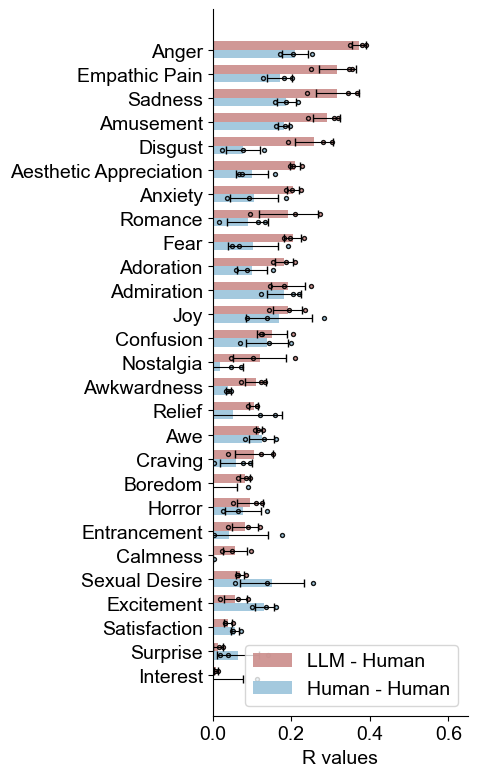

In [50]:
fig, ax = plt.subplots(figsize=(5, 8))
plt.rcParams['font.size'] = 14

n_emos = len(emos_reorder)
y = np.arange(n_emos)
bar_height = 0.35

# ---- 先算均值和标准差，并按 inds_sorted 排序 ----
mean_llm = np.mean(r_llm_human_danmu[inds_sorted, :], axis=1)
std_llm  = np.std(r_llm_human_danmu[inds_sorted, :], axis=1)

r_human_danmu_vec = np.zeros((n_emos, 3))
for i in range(n_emos):
    r_human_danmu_vec[i] = r_human_danmu[i, :, :][triu_inds]

mean_human = np.mean(r_human_danmu_vec[inds_sorted, :], axis=1)
std_human  = np.std(r_human_danmu_vec[inds_sorted, :], axis=1)

# ---- 水平 bar：LLM / Human ----
bar_llm = ax.barh(
    y - bar_height/2, mean_llm, bar_height,
    xerr=std_llm,
    error_kw={'capsize': 3, 'elinewidth': 0.8},
    color=[203/255,141/255,139/255],
    alpha=0.9
)

bar_human = ax.barh(
    y + bar_height/2, mean_human, bar_height,
    xerr=std_human,
    error_kw={'capsize': 3, 'elinewidth': 0.8},
    color=[154/255,196/255,219/255],
    alpha=0.9
)

# ---- 散点：固定 y，改变 x ----
for i in range(n_emos):
    # LLM - Human
    ax.scatter(
        r_llm_human_danmu[inds_sorted[i], :],                     # x
        np.full_like(r_llm_human_danmu[inds_sorted[i], :],
                     y[i] - bar_height/2, dtype=float),           # y
        color=[203/255, 141/255, 139/255],
        s=8,
        edgecolor='black',
        alpha=0.9
    )
    # Human - Human
    ax.scatter(
        r_human_danmu[inds_sorted[i], :, :][triu_inds],           # x
        np.full_like(r_human_danmu[inds_sorted[i], :, :][triu_inds],
                     y[i] + bar_height/2, dtype=float),           # y
        color=[154/255, 196/255, 219/255],
        s=8,
        edgecolor='black',
        alpha=0.9
    )

# ---- 轴 & 图例 ----
ax.set_yticks(y)
ax.set_yticklabels(emos_sorted, fontsize=14)
ax.set_xlabel('R values', fontsize=14)

# 从上到下：LLM–Human 的 r 从大到小
ax.invert_yaxis()   # 关键：第一行在最上面

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 图例只用 bar 的色块
handles = [bar_llm[0], bar_human[0]]
labels = ['LLM - Human', 'Human - Human']
ax.legend(handles, labels, fontsize=14, loc='lower right')

# 坐标轴范围保持原来的 [0, 0.53]
ax.set_xlim(0, 0.65)

plt.tight_layout()
plt.savefig('figures/r_llm_human_danmu_27emo_barh.svg', dpi=300, bbox_inches='tight')
plt.show()
